# Step 1: Loading Libraries and Data
In this step, we import the necessary Python libraries for data manipulation, visualization, and machine learning. We also load the dataset from the CSV file.

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
df = pd.read_csv('training.csv')
df.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


# Step 2: Data Quality Check
Before visualization, we check for missing values (NaN), duplicates, and data types to avoid errors during analysis and modeling.

In [12]:
print("--- Missing Values ---")
print(df.isnull().sum())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

print("\n--- Data Info ---")
df.info()

open_no_sales = df[(df['open'] == 1) & (df['sales'] == 0)]
print(f"\nDays with store open but 0 sales: {len(open_no_sales)}")

--- Missing Values ---
Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

Number of duplicate rows: 0

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   state_holiday        640840 non-null  object
 8   school_holiday       640840 non-null  int64 
 9   

# Step 3: Statistical Overview
Looking at the descriptive statistics to understand the range, mean, and potential outliers in our sales and customer data.

In [13]:
display(df.describe())
print(f"Unique stores: {df['store_ID'].nunique()}")

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


Unique stores: 1115


# Step 4: Visual Data Exploration
Relationship between sales, customers, and promotions.

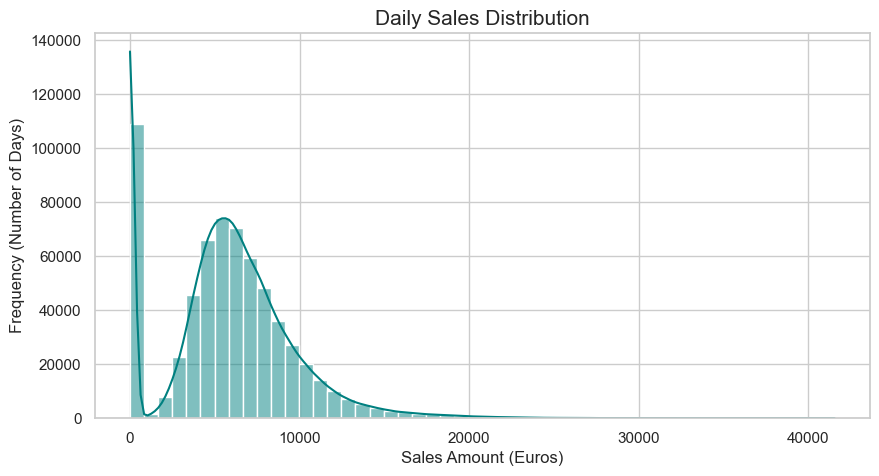

In [14]:
sns.set_theme(style="whitegrid")

# 1. Distribution of Daily Sales (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df['sales'], bins=50, color='teal', kde=True)
plt.title('Daily Sales Distribution', fontsize=15)
plt.xlabel('Sales Amount (Euros)', fontsize=12)
plt.ylabel('Frequency (Number of Days)', fontsize=12)
plt.show()

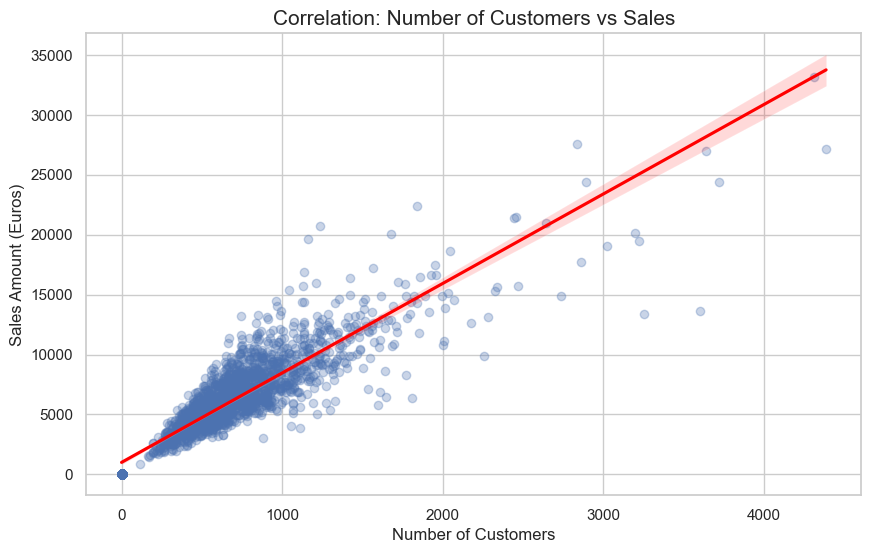

In [15]:
# 2. Customers and Sales

plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(2000), x='nb_customers_on_day', y='sales', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation: Number of Customers vs Sales', fontsize=15)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Sales Amount (Euros)', fontsize=12)
plt.show()

/var/folders/_w/q8p_cs1d7nz7tsmlmhpvk1zc0000gn/T/ipykernel_39618/541399074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='promotion', y='sales', palette='Set2')


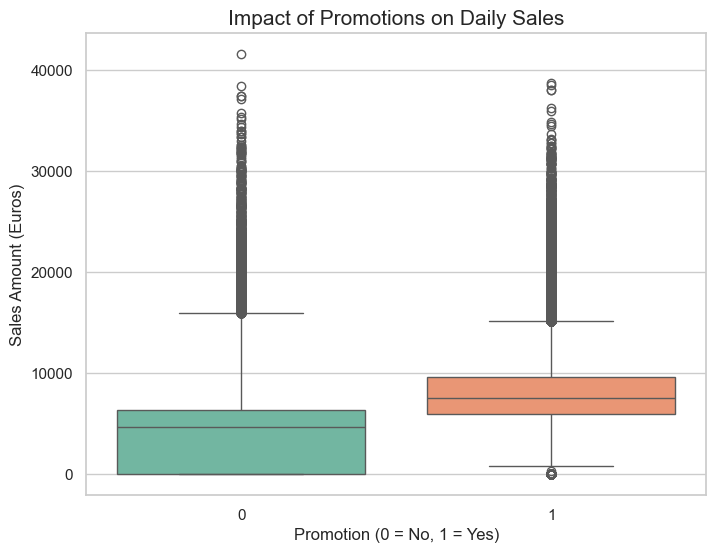

In [16]:
# 3. Impact of Promotions on Sales (Boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='promotion', y='sales', palette='Set2')
plt.title('Impact of Promotions on Daily Sales', fontsize=15)
plt.xlabel('Promotion (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Sales Amount (Euros)', fontsize=12)
plt.show()

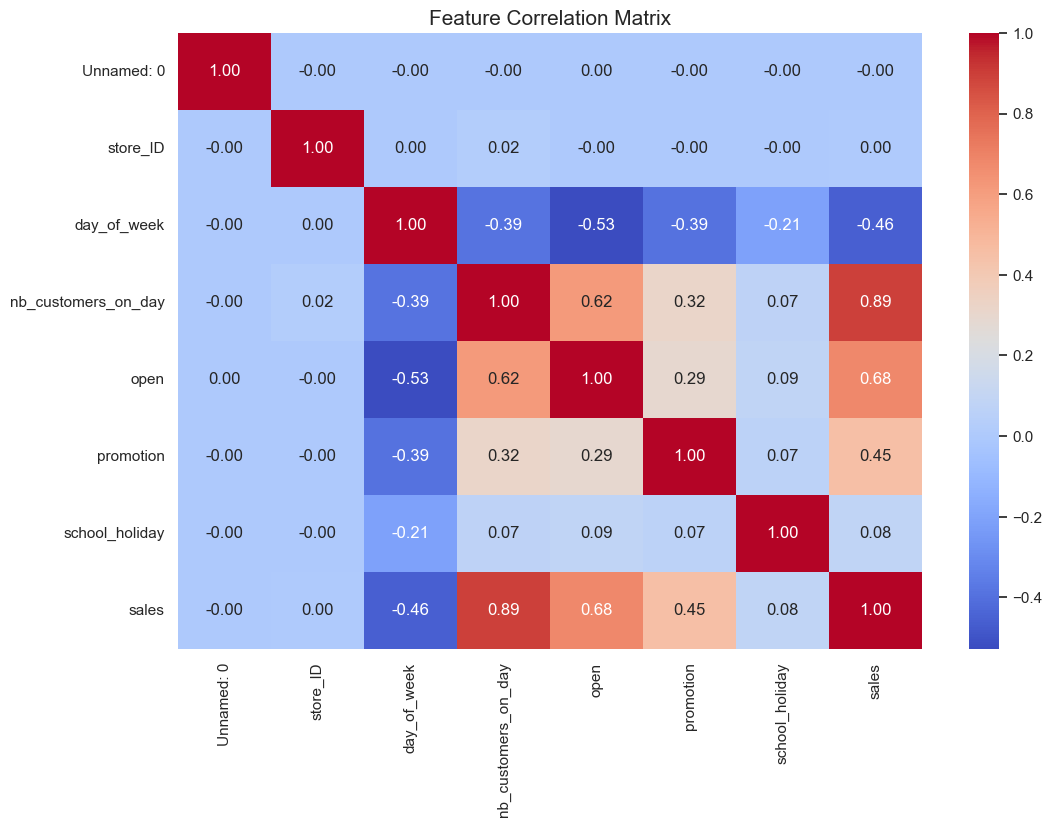

In [17]:
# 4. Feature Correlation Matrix (Heatmap)
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=15)
plt.show()

# Step 5: Feature Engineering and Data Splitting
We convert the 'date' column into numerical features (Year, Month, Day) and remove non-numerical columns. Then we split the data into training (80%) and testing (20%) sets.

In [18]:
# Convert date to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Extract numerical parts
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week_num'] = df['date'].dt.dayofweek

# Check the new columns
df[['date', 'year', 'month', 'day', 'day_of_week_num']].head()

,date,year,month,day,day_of_week_num
0,2013-04-18,2013,4,18,3
1,2015-04-11,2015,4,11,5
2,2013-08-29,2013,8,29,3
3,2013-05-28,2013,5,28,1
4,2013-10-10,2013,10,10,3


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Convert state_holiday to string then encode
df['state_holiday'] = le.fit_transform(df['state_holiday'].astype(str))

# Verify the change
print("Unique values in state_holiday:", df['state_holiday'].unique())


Unique values in state_holiday: [0 1 3 2]


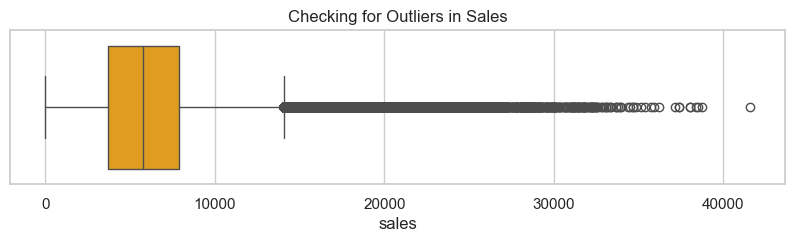

Days with sales > 30,000: 107


In [22]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['sales'], color='orange')
plt.title('Checking for Outliers in Sales')
plt.show()

extreme_sales = df[df['sales'] > 30000]
print(f"Days with sales > 30,000: {len(extreme_sales)}")

In [23]:

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

X = df.drop(['sales', 'date'], axis=1)
y = df['sales']

print("Final Features for Training:")
print(X.columns.tolist())
print(f"\nShape of X: {X.shape}")

Final Features for Training:
['store_ID', 'day_of_week', 'nb_customers_on_day', 'open', 'promotion', 'state_holiday', 'school_holiday', 'year', 'month', 'day', 'day_of_week_num']

Shape of X: (640840, 11)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successful!")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")

Data split successful!
Training set: 512672 rows
Validation set: 128168 rows


Feature Scaling (Standardization)

In [31]:
from sklearn.preprocessing import StandardScaler
#columns to scale
cols_to_scale = ['nb_customers_on_day', 'year', 'month', 'day', 'day_of_week_num']
scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val[cols_to_scale] = scaler.transform(X_val[cols_to_scale])

print("Scaling finished! Your data is now ready for modeling.")

Scaling finished! Your data is now ready for modeling.


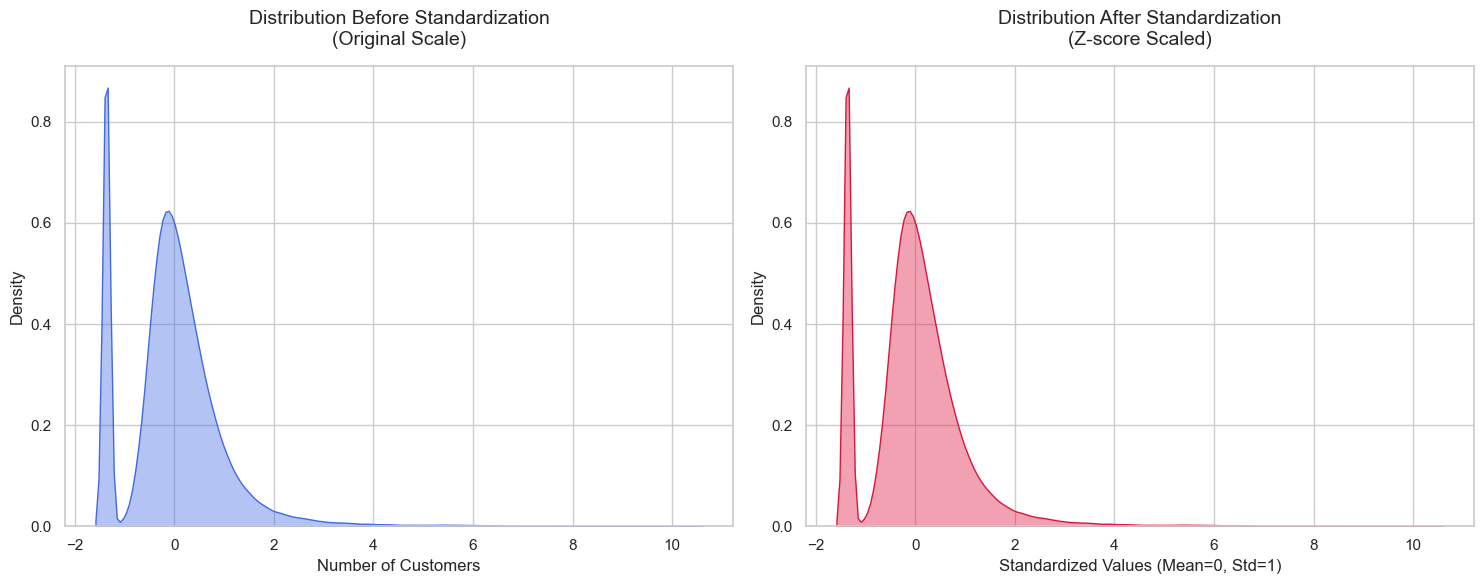

Original Mean: 0.00
Scaled Mean:   0.00 (Target: ~0)
Scaled Std:    1.00 (Target: 1)


In [32]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 6))

# Plot 1: Before Standardization
sns.kdeplot(X_train['nb_customers_on_day'], ax=ax1, color='royalblue', fill=True, alpha=0.4)
ax1.set_title('Distribution Before Standardization\n(Original Scale)', fontsize=14, pad=15)
ax1.set_xlabel('Number of Customers', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)

# Plot 2: After Standardization
sns.kdeplot(X_train_scaled['nb_customers_on_day'], ax=ax2, color='crimson', fill=True, alpha=0.4)
ax2.set_title('Distribution After Standardization\n(Z-score Scaled)', fontsize=14, pad=15)
ax2.set_xlabel('Standardized Values (Mean=0, Std=1)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
plt.tight_layout()
plt.show()

# Verification metrics for the presentation
print(f"Original Mean: {X_train['nb_customers_on_day'].mean():.2f}")
print(f"Scaled Mean:   {X_train_scaled['nb_customers_on_day'].mean():.2f} (Target: ~0)")
print(f"Scaled Std:    {X_train_scaled['nb_customers_on_day'].std():.2f} (Target: 1)")

Correlation with Sales:
 sales                  1.000000
nb_customers_on_day    0.894872
open                   0.678463
promotion              0.451819
school_holiday         0.084484
month                  0.049465
date                   0.041123
year                   0.022520
store_ID               0.004804
day                   -0.011607
state_holiday         -0.229315
day_of_week_num       -0.461107
day_of_week           -0.461107
Name: sales, dtype: float64


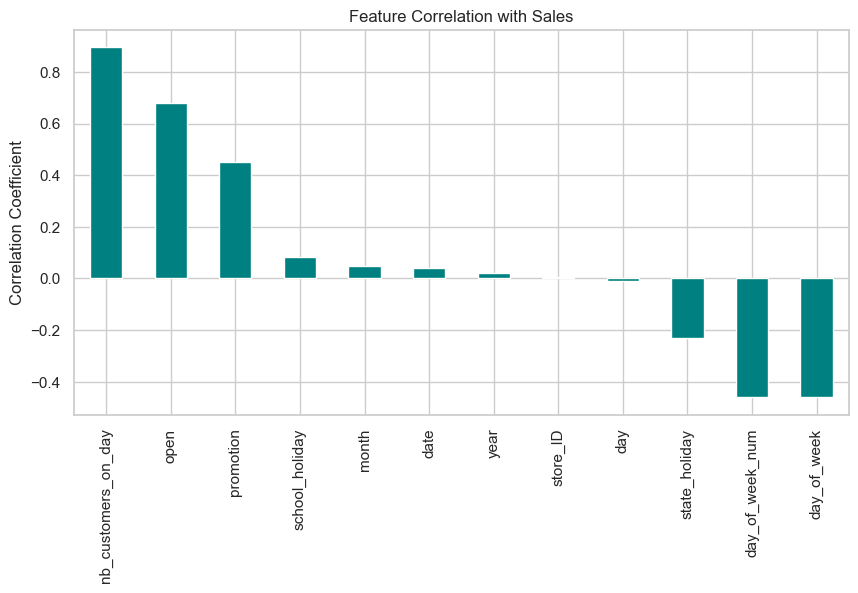

In [ ]:
# Which features correlate most with sales
correlation = df.corr()['sales'].sort_values(ascending=False)
print("Correlation with Sales:\n", correlation)

plt.figure(figsize=(10, 5))
correlation.drop('sales').plot(kind='bar', color='teal')
plt.title('Feature Correlation with Sales')
plt.ylabel('Correlation Coefficient')
plt.show()

# Step 6.1: Picking the right model
We start with Linear Regression and R2 score calculation

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train) 
train_r2 = r2_score(y_train, y_pred_train)

y_pred_val = lr.predict(X_val)
val_r2 = r2_score(y_val, y_pred_val)

print(f"Linear Regression Train R2:      {train_r2:.4f}")
print(f"Linear Regression Validation R2: {val_r2:.4f}")

Linear Regression Train R2:      0.8547
Linear Regression Validation R2: 0.8520


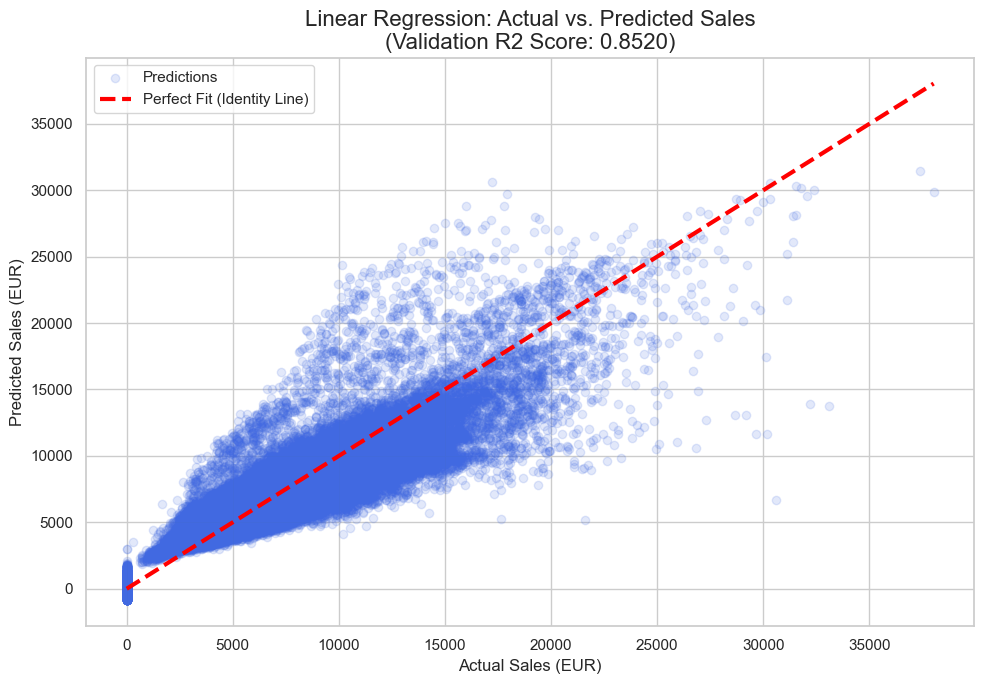

In [43]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))

plt.scatter(y_val, y_pred_val, alpha=0.15, color='royalblue', label='Predictions')

line_coords = [y_val.min(), y_val.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=3, label='Perfect Fit (Identity Line)')

plt.title(f'Linear Regression: Actual vs. Predicted Sales\n(Validation R2 Score: {val_r2:.4f})', fontsize=16)
plt.xlabel('Actual Sales (EUR)', fontsize=12)
plt.ylabel('Predicted Sales (EUR)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

Next to test Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dt = DecisionTreeRegressor(random_state=42, max_depth=10)

dt.fit(X_train, y_train)
y_pred_dt_train = dt.predict(X_train)
dt_train_r2 = r2_score(y_train, y_pred_dt_train)

y_pred_dt_val = dt.predict(X_val)
dt_val_r2 = r2_score(y_val, y_pred_dt_val)

print(f"Decision Tree Train R2:      {dt_train_r2:.4f}")
print(f"Decision Tree Validation R2: {dt_val_r2:.4f}")

Decision Tree Train R2:      0.9588
Decision Tree Validation R2: 0.9100


In [51]:
depths = [2, 5, 10, 15, 20, 30]
for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    train_score = r2_score(y_train, model.predict(X_train))
    val_score = r2_score(y_val, model.predict(X_val))
    
    diff = train_score - val_score
    print(f"Depth: {d:2} | Train R2: {train_score:.4f} | Val R2: {val_score:.4f} | Difference: {diff:.4f}")

Depth:  2 | Train R2: 0.7297 | Val R2: 0.7312 | Difference: -0.0016
Depth:  5 | Train R2: 0.8584 | Val R2: 0.8561 | Difference: 0.0023
Depth: 10 | Train R2: 0.8913 | Val R2: 0.8869 | Difference: 0.0044
Depth: 15 | Train R2: 0.9231 | Val R2: 0.9048 | Difference: 0.0183
Depth: 20 | Train R2: 0.9588 | Val R2: 0.9100 | Difference: 0.0488
Depth: 30 | Train R2: 0.9952 | Val R2: 0.9041 | Difference: 0.0911


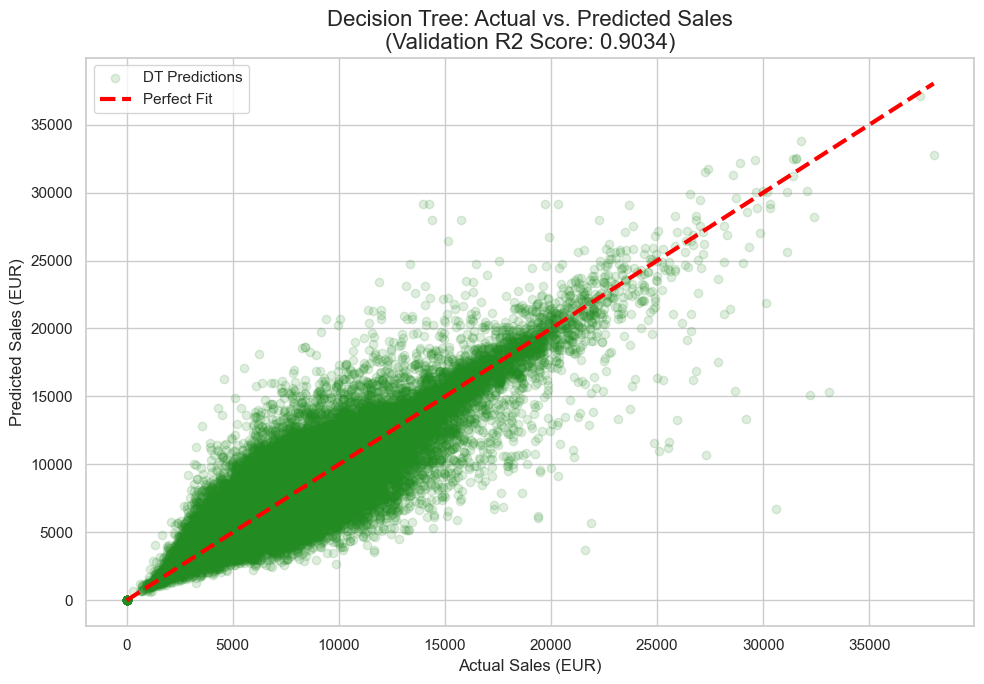

In [52]:
plt.figure(figsize=(10, 7))

plt.scatter(y_val, y_pred_dt, alpha=0.15, color='forestgreen', label='DT Predictions')


line_coords = [y_val.min(), y_val.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=3, label='Perfect Fit')

plt.title(f'Decision Tree: Actual vs. Predicted Sales\n(Validation R2 Score: {dt_r2:.4f})', fontsize=16)
plt.xlabel('Actual Sales (EUR)', fontsize=12)
plt.ylabel('Predicted Sales (EUR)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

KNN model

In [53]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score


knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn_train = knn.predict(X_train)
knn_train_r2 = r2_score(y_train, y_pred_knn_train)

y_pred_knn_val = knn.predict(X_val)
knn_val_r2 = r2_score(y_val, y_pred_knn_val)

print(f"--- K-Nearest Neighbors ---")
print(f"KNN Train R2:      {knn_train_r2:.4f}")
print(f"KNN Validation R2: {knn_val_r2:.4f}")

--- K-Nearest Neighbors ---
KNN Train R2:      0.9562
KNN Validation R2: 0.9301
